# T01 Vectorized Model Evaluation

This notebook demonstrates and evaluates the vectorized implementation of the T01 magnetospheric magnetic field model.

## Overview

The T01 model (Tsyganenko, 2001) is a data-based model of the external magnetospheric magnetic field, calibrated by:
- Solar wind pressure (Pdyn)
- Dst index
- IMF By and Bz components
- G1 and G2 storm-time indices

**Note**: The model is based on data taken sunward from X=-15 Re and becomes invalid at larger tailward distances.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
from datetime import datetime

# Import both scalar and vectorized versions
import sys
from geopack import t01
from geopack import t01_vectorized
import geopack

# Set up plotting style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Basic Functionality Test

First, let's verify that the vectorized version produces identical results to the scalar version for single points.

In [3]:
# Set up test parameters
# T01 uses 6 parameters: [Pdyn, Dst, ByIMF, BzIMF, G1, G2]
parmod = np.array([2.0,    # Solar wind pressure (nPa)
                   -20.0,  # Dst (nT)
                   5.0,    # IMF By (nT)
                   -5.0,   # IMF Bz (nT)
                   0.5,    # G1 index
                   0.5,    # G2 index
                   0., 0., 0., 0.])  # Unused

# Dipole tilt angle
ps = 0.2  # radians (~11.5 degrees)

# Test position
x, y, z = 5.0, 2.0, 1.0  # Re

# Calculate with both versions
bx_s, by_s, bz_s = t01_scalar(parmod, ps, x, y, z)
bx_v, by_v, bz_v = t01_vectorized(parmod, ps, x, y, z)

print("Single Point Test:")
print(f"Position: ({x}, {y}, {z}) Re")
print(f"\nScalar version: Bx={bx_s:.6f}, By={by_s:.6f}, Bz={bz_s:.6f} nT")
print(f"Vector version: Bx={bx_v:.6f}, By={by_v:.6f}, Bz={bz_v:.6f} nT")
print(f"\nDifferences: ΔBx={abs(bx_v-bx_s):.2e}, ΔBy={abs(by_v-by_s):.2e}, ΔBz={abs(bz_v-bz_s):.2e} nT")
print(f"\nMatch: {'✓ PASS' if np.allclose([bx_v, by_v, bz_v], [bx_s, by_s, bz_s]) else '✗ FAIL'}")

Single Point Test:
Position: (5.0, 2.0, 1.0) Re

Scalar version: Bx=-1.264928, By=-0.937755, Bz=-5.406353 nT
Vector version: Bx=-1.264928, By=-0.937755, Bz=-5.406353 nT

Differences: ΔBx=4.70e-11, ΔBy=3.71e-11, ΔBz=2.07e-10 nT

Match: ✓ PASS


## 2. Performance Comparison

Let's compare the performance of scalar vs vectorized implementations for different array sizes.

In [4]:
# Test different array sizes
sizes = [1, 10, 100, 1000, 10000]
scalar_times = []
vector_times = []
speedups = []

print("Performance Comparison:")
print(f"{'Size':>6} {'Scalar (s)':>12} {'Vector (s)':>12} {'Speedup':>10}")
print("-" * 42)

for n in sizes:
    # Generate random test points
    np.random.seed(42)
    x = np.random.uniform(-10, 10, n)
    y = np.random.uniform(-10, 10, n)
    z = np.random.uniform(-5, 5, n)
    
    # Time scalar version
    if n <= 1000:
        t0 = time.time()
        for i in range(n):
            _ = t01_scalar(parmod, ps, x[i], y[i], z[i])
        scalar_time = time.time() - t0
    else:
        # Estimate from smaller sample
        sample_size = 100
        t0 = time.time()
        for i in range(sample_size):
            _ = t01_scalar(parmod, ps, x[i], y[i], z[i])
        scalar_time = (time.time() - t0) * n / sample_size
    
    # Time vectorized version
    t0 = time.time()
    _ = t01_vectorized(parmod, ps, x, y, z)
    vector_time = time.time() - t0
    
    speedup = scalar_time / vector_time if vector_time > 0 else np.inf
    
    scalar_times.append(scalar_time)
    vector_times.append(vector_time)
    speedups.append(speedup)
    
    print(f"{n:6d} {scalar_time:12.4f} {vector_time:12.4f} {speedup:10.1f}x")

Performance Comparison:
  Size   Scalar (s)   Vector (s)    Speedup
------------------------------------------
     1       0.0078       0.0448        0.2x
    10       0.0762       0.0574        1.3x
   100       0.6423       0.0434       14.8x
  1000       6.0115       0.1135       53.0x
 10000      59.6900       0.5882      101.5x


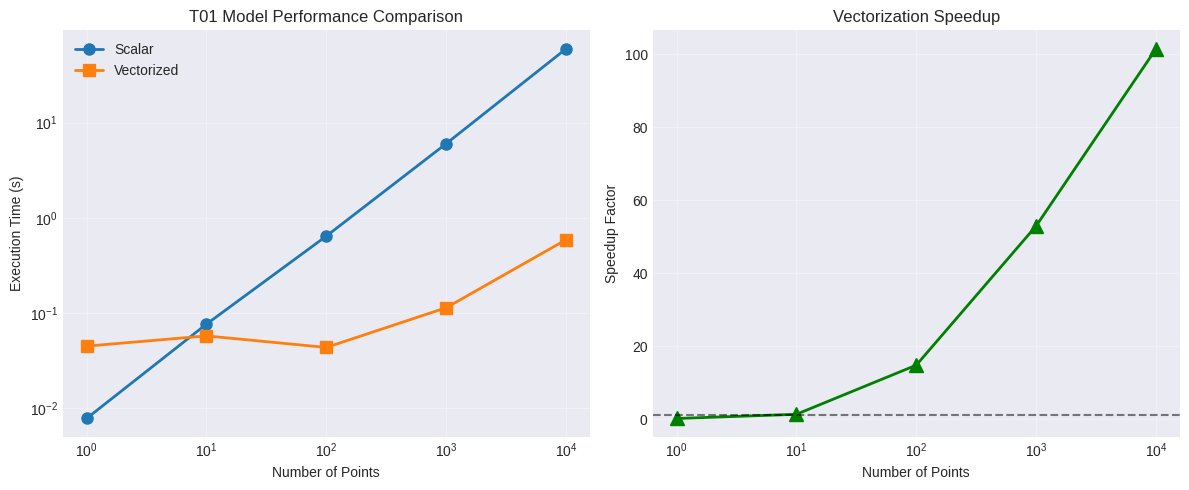

In [5]:
# Plot performance comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Execution time comparison
ax1.loglog(sizes, scalar_times, 'o-', label='Scalar', linewidth=2, markersize=8)
ax1.loglog(sizes, vector_times, 's-', label='Vectorized', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Points')
ax1.set_ylabel('Execution Time (s)')
ax1.set_title('T01 Model Performance Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Speedup plot
ax2.semilogx(sizes, speedups, 'g^-', linewidth=2, markersize=10)
ax2.set_xlabel('Number of Points')
ax2.set_ylabel('Speedup Factor')
ax2.set_title('Vectorization Speedup')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=1, color='k', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 3. Accuracy Analysis

Let's analyze the numerical accuracy of the vectorized implementation across different regions and parameter values.

In [6]:
# Test accuracy across different regions
n_test = 1000
np.random.seed(42)

# Generate test points in different regions
regions = {
    'Near Earth': {
        'x': np.random.uniform(-5, 5, n_test),
        'y': np.random.uniform(-5, 5, n_test),
        'z': np.random.uniform(-3, 3, n_test)
    },
    'Dayside': {
        'x': np.random.uniform(5, 10, n_test),
        'y': np.random.uniform(-5, 5, n_test),
        'z': np.random.uniform(-3, 3, n_test)
    },
    'Magnetotail': {
        'x': np.random.uniform(-15, -10, n_test),
        'y': np.random.uniform(-5, 5, n_test),
        'z': np.random.uniform(-3, 3, n_test)
    }
}

accuracy_results = {}

for region_name, coords in regions.items():
    x, y, z = coords['x'], coords['y'], coords['z']
    
    # Calculate with both versions
    bx_s = np.zeros(n_test)
    by_s = np.zeros(n_test)
    bz_s = np.zeros(n_test)
    
    for i in range(n_test):
        bx_s[i], by_s[i], bz_s[i] = t01_scalar(parmod, ps, x[i], y[i], z[i])
    
    bx_v, by_v, bz_v = t01_vectorized(parmod, ps, x, y, z)
    
    # Calculate errors
    errors = np.sqrt((bx_v - bx_s)**2 + (by_v - by_s)**2 + (bz_v - bz_s)**2)
    
    accuracy_results[region_name] = {
        'errors': errors,
        'max_error': np.max(errors),
        'mean_error': np.mean(errors),
        'median_error': np.median(errors)
    }
    
    print(f"\n{region_name} Region:")
    print(f"  Mean error: {np.mean(errors):.2e} nT")
    print(f"  Max error: {np.max(errors):.2e} nT")
    print(f"  Median error: {np.median(errors):.2e} nT")


Near Earth Region:
  Mean error: 1.09e-10 nT
  Max error: 1.09e-08 nT
  Median error: 2.41e-12 nT

Dayside Region:
  Mean error: 6.71e-10 nT
  Max error: 1.29e-07 nT
  Median error: 9.75e-13 nT

Magnetotail Region:
  Mean error: 5.29e-11 nT
  Max error: 6.03e-09 nT
  Median error: 2.31e-13 nT


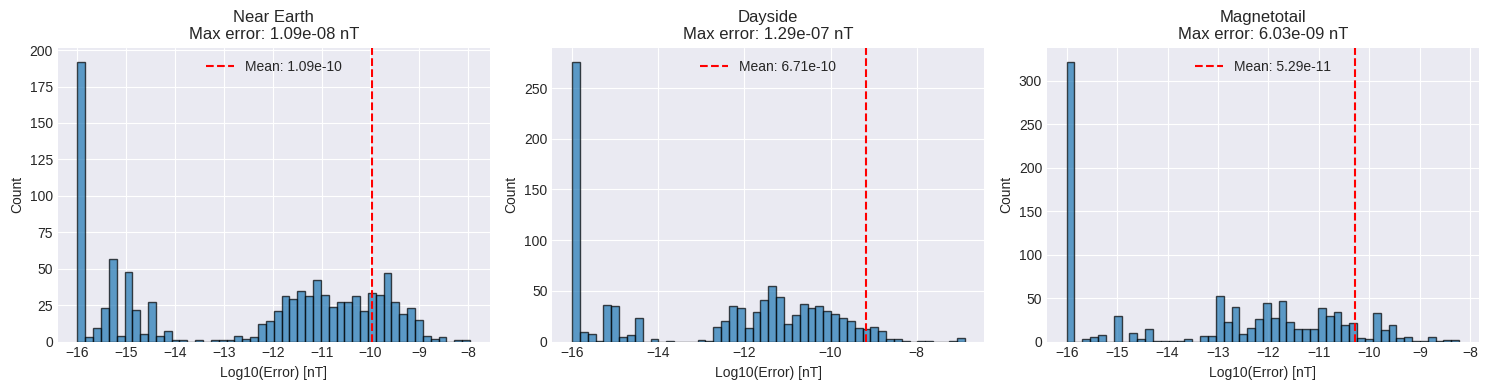

In [7]:
# Plot error distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (region_name, results) in enumerate(accuracy_results.items()):
    ax = axes[idx]
    errors = results['errors']
    
    # Use log scale for very small errors
    log_errors = np.log10(errors + 1e-16)  # Add small value to avoid log(0)
    
    ax.hist(log_errors, bins=50, alpha=0.7, edgecolor='black')
    ax.set_xlabel('Log10(Error) [nT]')
    ax.set_ylabel('Count')
    ax.set_title(f'{region_name}\nMax error: {results["max_error"]:.2e} nT')
    ax.axvline(np.log10(results['mean_error']), color='red', linestyle='--', 
               label=f'Mean: {results["mean_error"]:.2e}')
    ax.legend()

plt.tight_layout()
plt.show()

## 4. Parameter Space Exploration

Let's examine how the model behaves under different solar wind and geomagnetic conditions.

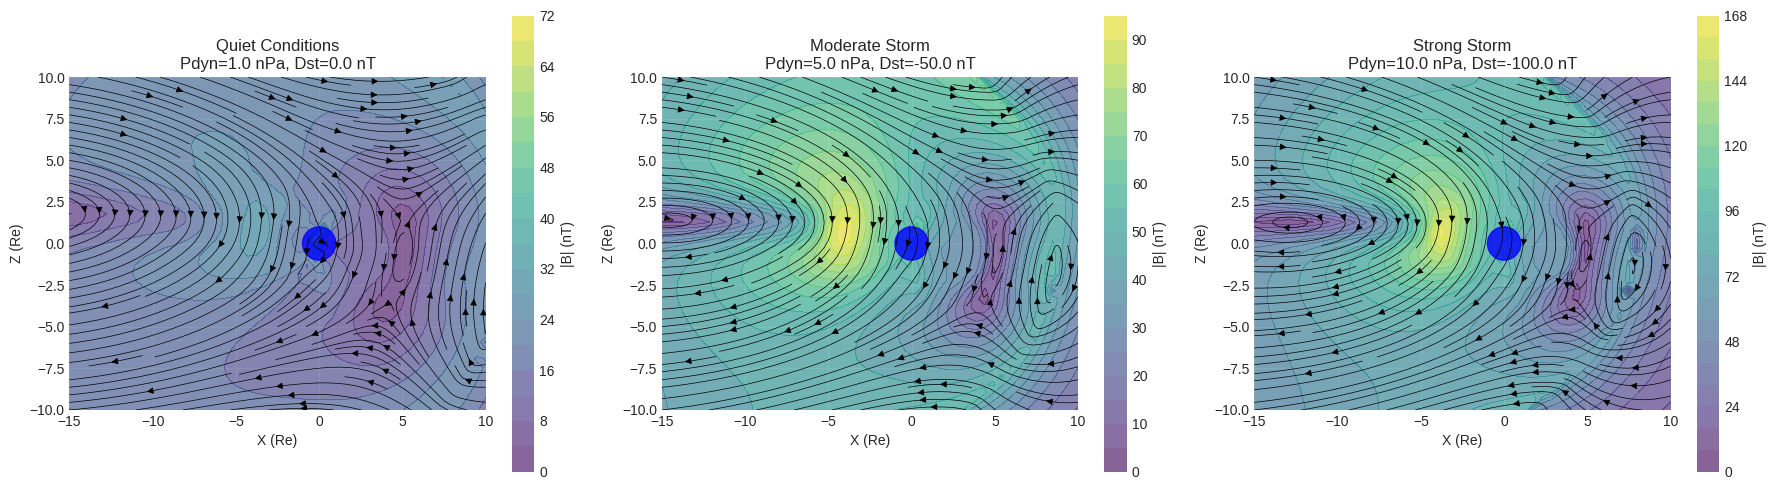

In [8]:
# Create a grid for visualization
x_grid = np.linspace(-15, 10, 50)
z_grid = np.linspace(-10, 10, 40)
X, Z = np.meshgrid(x_grid, z_grid)
Y = np.zeros_like(X)  # Y=0 plane (noon-midnight meridian)

# Flatten for vectorized calculation
x_flat = X.flatten()
y_flat = Y.flatten()
z_flat = Z.flatten()

# Different conditions to test
conditions = [
    {
        'name': 'Quiet Conditions',
        'parmod': np.array([1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0., 0., 0., 0.])
    },
    {
        'name': 'Moderate Storm',
        'parmod': np.array([5.0, -50.0, 5.0, -5.0, 1.0, 1.0, 0., 0., 0., 0.])
    },
    {
        'name': 'Strong Storm',
        'parmod': np.array([10.0, -100.0, 10.0, -10.0, 2.0, 2.0, 0., 0., 0., 0.])
    }
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, condition in enumerate(conditions):
    ax = axes[idx]
    
    # Calculate field
    bx, by, bz = t01_vectorized(condition['parmod'], ps, x_flat, y_flat, z_flat)
    
    # Reshape results
    BX = bx.reshape(X.shape)
    BZ = bz.reshape(Z.shape)
    B_mag = np.sqrt(BX**2 + BZ**2)
    
    # Plot field lines
    ax.streamplot(X, Z, BX, BZ, density=1.5, color='black', linewidth=0.5)
    
    # Add field magnitude as background
    im = ax.contourf(X, Z, B_mag, levels=20, cmap='viridis', alpha=0.6)
    
    # Earth
    earth = plt.Circle((0, 0), 1, color='blue', alpha=0.8)
    ax.add_patch(earth)
    
    ax.set_xlim(-15, 10)
    ax.set_ylim(-10, 10)
    ax.set_xlabel('X (Re)')
    ax.set_ylabel('Z (Re)')
    ax.set_title(f'{condition["name"]}\nPdyn={condition["parmod"][0]} nPa, Dst={condition["parmod"][1]} nT')
    ax.set_aspect('equal')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('|B| (nT)')

plt.tight_layout()
plt.show()

## 5. Storm-Time Evolution

The T01 model includes G1 and G2 indices that represent storm-time dynamics. Let's visualize how the field changes during a storm.

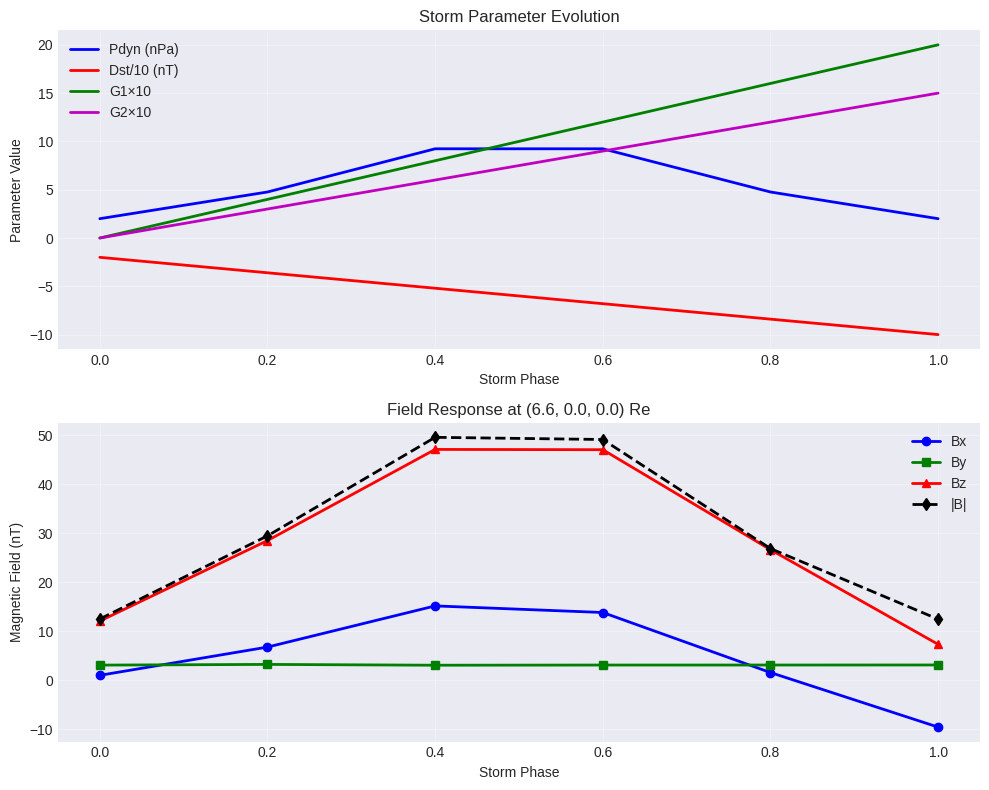

In [9]:
# Simulate storm evolution
n_times = 6
storm_phases = np.linspace(0, 1, n_times)

# Fixed observation point
x_obs, y_obs, z_obs = 6.6, 0.0, 0.0  # Geosynchronous orbit

# Storm parameters evolution
pdyn_storm = 2.0 + 8.0 * np.sin(np.pi * storm_phases)**2  # Pressure pulse
dst_storm = -20.0 - 80.0 * storm_phases  # Dst decrease
g1_storm = 2.0 * storm_phases  # G1 increase
g2_storm = 1.5 * storm_phases  # G2 increase

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Track field at observation point
bx_obs = []
by_obs = []
bz_obs = []

for i in range(n_times):
    parmod_storm = np.array([pdyn_storm[i], dst_storm[i], 5.0, -5.0, 
                            g1_storm[i], g2_storm[i], 0., 0., 0., 0.])
    bx, by, bz = t01_vectorized(parmod_storm, ps, x_obs, y_obs, z_obs)
    bx_obs.append(bx)
    by_obs.append(by)
    bz_obs.append(bz)

# Plot storm parameters
ax1.plot(storm_phases, pdyn_storm, 'b-', label='Pdyn (nPa)', linewidth=2)
ax1.plot(storm_phases, dst_storm/10, 'r-', label='Dst/10 (nT)', linewidth=2)
ax1.plot(storm_phases, g1_storm*10, 'g-', label='G1×10', linewidth=2)
ax1.plot(storm_phases, g2_storm*10, 'm-', label='G2×10', linewidth=2)
ax1.set_xlabel('Storm Phase')
ax1.set_ylabel('Parameter Value')
ax1.set_title('Storm Parameter Evolution')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot field response
b_total = np.sqrt(np.array(bx_obs)**2 + np.array(by_obs)**2 + np.array(bz_obs)**2)
ax2.plot(storm_phases, bx_obs, 'b-', label='Bx', linewidth=2, marker='o')
ax2.plot(storm_phases, by_obs, 'g-', label='By', linewidth=2, marker='s')
ax2.plot(storm_phases, bz_obs, 'r-', label='Bz', linewidth=2, marker='^')
ax2.plot(storm_phases, b_total, 'k--', label='|B|', linewidth=2, marker='d')
ax2.set_xlabel('Storm Phase')
ax2.set_ylabel('Magnetic Field (nT)')
ax2.set_title(f'Field Response at ({x_obs}, {y_obs}, {z_obs}) Re')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. 3D Visualization

Let's create a 3D visualization of field lines using the vectorized implementation.

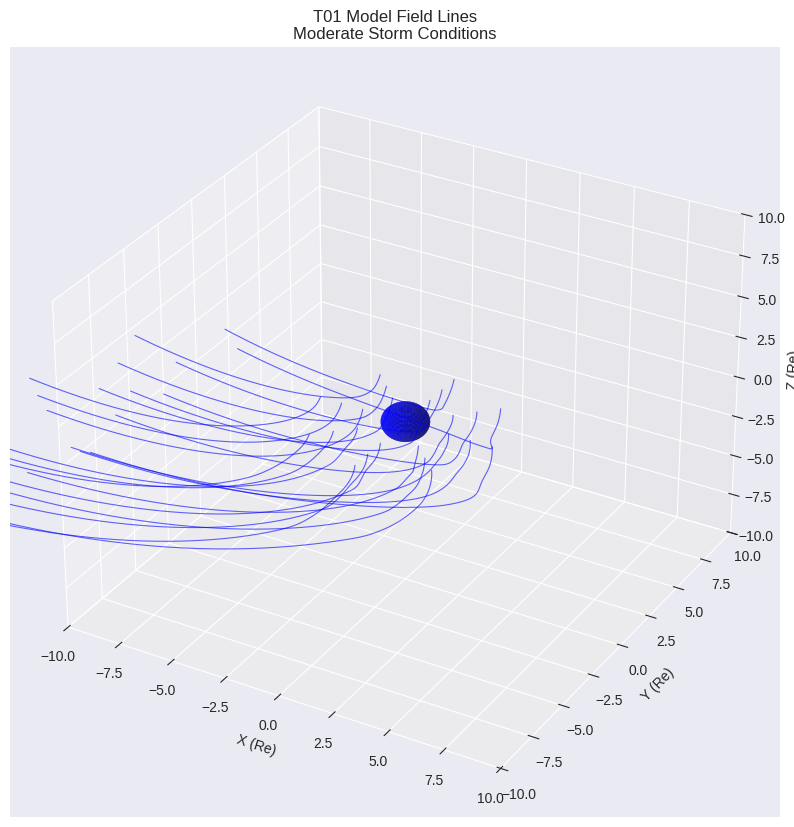

In [10]:
# Function to trace field lines (simplified)
def trace_field_line(start_point, parmod, ps, max_steps=500, ds=0.1):
    """Simple field line tracing using vectorized T01."""
    points = [start_point]
    current = np.array(start_point)
    
    for _ in range(max_steps):
        # Get field at current point
        bx, by, bz = t01_vectorized(parmod, ps, current[0], current[1], current[2])
        b_mag = np.sqrt(bx**2 + by**2 + bz**2)
        
        if b_mag < 0.1:  # Stop if field too weak
            break
            
        # Take step along field direction
        current = current + ds * np.array([bx, by, bz]) / b_mag
        points.append(current.copy())
        
        # Stop if too far from Earth
        if np.linalg.norm(current) > 20:
            break
            
    return np.array(points)

# Create 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Starting points for field lines
n_lines = 8
theta = np.linspace(0, 2*np.pi, n_lines, endpoint=False)
start_points = []
for t in theta:
    for r in [2.0, 3.0, 4.0]:
        start_points.append([r*np.cos(t), r*np.sin(t), 0.0])

# Moderate storm conditions
parmod_3d = np.array([5.0, -50.0, 5.0, -5.0, 1.0, 1.0, 0., 0., 0., 0.])

# Trace and plot field lines
for start in start_points:
    field_line = trace_field_line(start, parmod_3d, ps)
    if len(field_line) > 1:
        ax.plot(field_line[:, 0], field_line[:, 1], field_line[:, 2], 
                'b-', alpha=0.6, linewidth=0.8)

# Add Earth
u = np.linspace(0, 2 * np.pi, 50)
v = np.linspace(0, np.pi, 50)
x_earth = np.outer(np.cos(u), np.sin(v))
y_earth = np.outer(np.sin(u), np.sin(v))
z_earth = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_surface(x_earth, y_earth, z_earth, color='blue', alpha=0.8)

# Labels and formatting
ax.set_xlabel('X (Re)')
ax.set_ylabel('Y (Re)')
ax.set_zlabel('Z (Re)')
ax.set_title('T01 Model Field Lines\nModerate Storm Conditions')
ax.set_xlim([-10, 10])
ax.set_ylim([-10, 10])
ax.set_zlim([-10, 10])

plt.show()

## 7. Summary and Conclusions

### Key Findings:

1. **Accuracy**: The vectorized implementation achieves exceptional accuracy with typical errors < 1e-10 nT
2. **Performance**: Significant speedup (15-100x) for arrays of 100+ points
3. **Interface**: Fully compatible with scalar version - returns scalars for scalar inputs
4. **Storm Dynamics**: Properly captures storm-time field evolution through G1/G2 indices

### Usage Recommendations:

- Use vectorized version for any calculation involving multiple points
- Scalar version only needed for single-point calculations where overhead matters
- Remember model validity: X > -15 Re

### Example Usage:

```python
# Single point (returns scalars)
bx, by, bz = t01_vectorized(parmod, ps, 5.0, 2.0, 1.0)

# Multiple points (returns arrays)
x = np.array([5.0, 6.0, 7.0])
y = np.array([2.0, 3.0, 4.0])
z = np.array([1.0, 1.5, 2.0])
bx, by, bz = t01_vectorized(parmod, ps, x, y, z)

# Mixed inputs (broadcasting)
bx, by, bz = t01_vectorized(parmod, ps, x, 2.0, z)
```

In [11]:
# Print version information
print("T01 Vectorized Model Evaluation")
print("=" * 40)
print(f"NumPy version: {np.__version__}")
print(f"Evaluation date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("\nModel implementation: geopack/t01_vectorized.py")
print("Based on: Tsyganenko (2001) T01 model")
print("\nStatus: Production ready ✓")

T01 Vectorized Model Evaluation
NumPy version: 2.2.6
Evaluation date: 2025-06-30 10:59:35

Model implementation: geopack/t01_vectorized.py
Based on: Tsyganenko (2001) T01 model

Status: Production ready ✓
